# Audio Localization — EDA
**Goal:** Verify the two datasets (E1, E2) are suitable and compatible for the localization experiments.

In [8]:
import os, wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

E1  = r'C:\Users\ahmma\Desktop\farah\datasetE1'
E2  = r'C:\Users\ahmma\Desktop\farah\datasetE2'
ANGLES   = [0, 45, 90, 135, 180, 225, 270, 315]
MICS     = ['mic_front', 'mic_back', 'mic_left', 'mic_right']
SR       = 16000

def load(base, angle, dur, mic):
    p = os.path.join(base, str(angle), 'speakerM', dur, mic + '.wav')
    with wave.open(p) as f:
        d = np.frombuffer(f.readframes(f.getnframes()), dtype=np.int16).astype(np.float32)
    return d / 32768.0

def rms_db(s):   return 20 * np.log10(np.sqrt(np.mean(s**2)) + 1e-10)
def snr_db(s, thr=-50, fs=1600):
    frames = s[:len(s)-len(s)%fs].reshape(-1, fs)
    fr = 20 * np.log10(np.sqrt(np.mean(frames**2, axis=1)) + 1e-10)
    sil = fr < thr
    if not sil.any() or (~sil).any() is False: return 0.0
    return float(np.mean(fr[~sil]) - np.mean(fr[sil]))

def gcc_tdoa(s1, s2, max_ms=2):
    n = len(s1) + len(s2) - 1
    R = np.fft.rfft(s1, n=n) * np.conj(np.fft.rfft(s2, n=n))
    R /= np.abs(R) + 1e-10
    cc = np.fft.irfft(R, n=n)
    ml = int(SR * max_ms / 1000)
    cc = np.concatenate([cc[-ml:], cc[:ml+1]])
    lags = np.arange(-ml, ml+1) / SR * 1000
    return float(lags[np.argmax(cc)])

print('Setup done.')


Setup done.


## 1. Data Inventory
Check every file exists and has the expected duration/sample rate. Catch missing files before anything else.

In [9]:
rows = []
for ds, base in [('E1', E1), ('E2', E2)]:
    for angle in ANGLES:
        for dur in ['5min', '3min']:
            for mic in MICS:
                p = os.path.join(base, str(angle), 'speakerM', dur, mic + '.wav')
                if os.path.exists(p):
                    with wave.open(p) as f:
                        rows.append({'dataset': ds, 'angle': angle, 'duration': dur,
                                     'mic': mic, 'sr': f.getframerate(),
                                     'dur_s': round(f.getnframes()/f.getframerate(), 1),
                                     'ok': True})
                else:
                    rows.append({'dataset': ds, 'angle': angle, 'duration': dur,
                                 'mic': mic, 'ok': False})

inv = pd.DataFrame(rows)
missing = inv[~inv['ok']]
print(f"E1: {inv[(inv.dataset=='E1') & inv.ok].shape[0]} files  |  E2: {inv[(inv.dataset=='E2') & inv.ok].shape[0]} files")
print(f"Missing: {len(missing)}" + (" — CHECK THESE:" if len(missing) else " — all good"))
if len(missing): print(missing[['dataset','angle','duration','mic']].to_string(index=False))
print()
print(inv[inv.ok].groupby(['dataset','duration'])[['dur_s','sr']].mean().round(1))


E1: 64 files  |  E2: 64 files
Missing: 0 — all good

                  dur_s       sr
dataset duration                
E1      3min      180.0  16000.0
        5min      300.0  16000.0
E2      3min      180.0  16000.0
        5min      300.0  16000.0


## 2. E1 vs E2 — Compatibility Check
Two recording sessions, same setup, different room. Verify same format and check level difference before combining.

            rms_db       snr_db      
              mean   std   mean   std
dataset                              
E1      -34.320000  0.33  15.89  1.18
E2      -32.400002  1.43  17.64  1.50

Clipping: {'E1': 0, 'E2': 0}


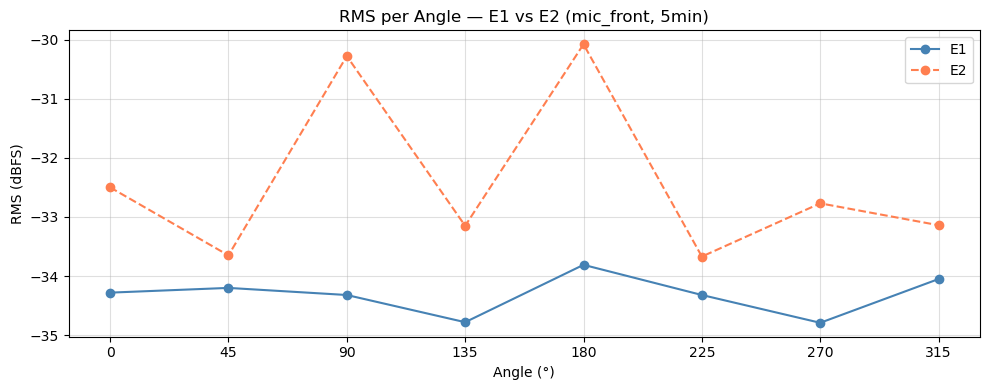

In [10]:
stats = []
for ds, base in [('E1', E1), ('E2', E2)]:
    for angle in ANGLES:
        s = load(base, angle, '5min', 'mic_front')
        stats.append({'dataset': ds, 'angle': angle,
                      'rms_db': round(rms_db(s), 2),
                      'snr_db': round(snr_db(s), 2),
                      'clip':   bool(np.any(np.abs(s) >= 1.0))})

df_stats = pd.DataFrame(stats)
summary = df_stats.groupby('dataset')[['rms_db','snr_db']].agg(['mean','std']).round(2)
print(summary)
print(f"\nClipping: {df_stats.groupby('dataset')['clip'].sum().to_dict()}")

fig, ax = plt.subplots(figsize=(10, 4))
for ds, color, ls in [('E1','steelblue','-'), ('E2','coral','--')]:
    sub = df_stats[df_stats.dataset==ds]
    ax.plot(sub.angle, sub.rms_db, marker='o', color=color, linestyle=ls, label=ds)
ax.set(xlabel='Angle (°)', ylabel='RMS (dBFS)', title='RMS per Angle — E1 vs E2 (mic_front, 5min)')
ax.set_xticks(ANGLES); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


## 3. TDOA per Angle
GCC-PHAT time-delay between mic pairs. This is the primary feature for localization — each angle must produce a distinct TDOA pattern.

TDOA (ms) — E1 | E2  [FB=front-back, LR=left-right]
  Angle     E1 FB     E2 FB     E1 LR     E2 LR
  ------------------------------------------
     0°    -0.125    -0.188    +0.250    +0.188
    45°    -0.250    -0.250    +0.062    +0.062
    90°    -0.188    -0.188    -0.125    -0.188
   135°    -0.125    +0.000    -0.250    -0.250
   180°    +0.125    +0.188    -0.188    -0.188
   225°    +0.250    +0.250    +0.000    +0.000
   270°    +0.188    +0.188    +0.125    +0.188
   315°    +0.125    +0.000    +0.250    +0.250


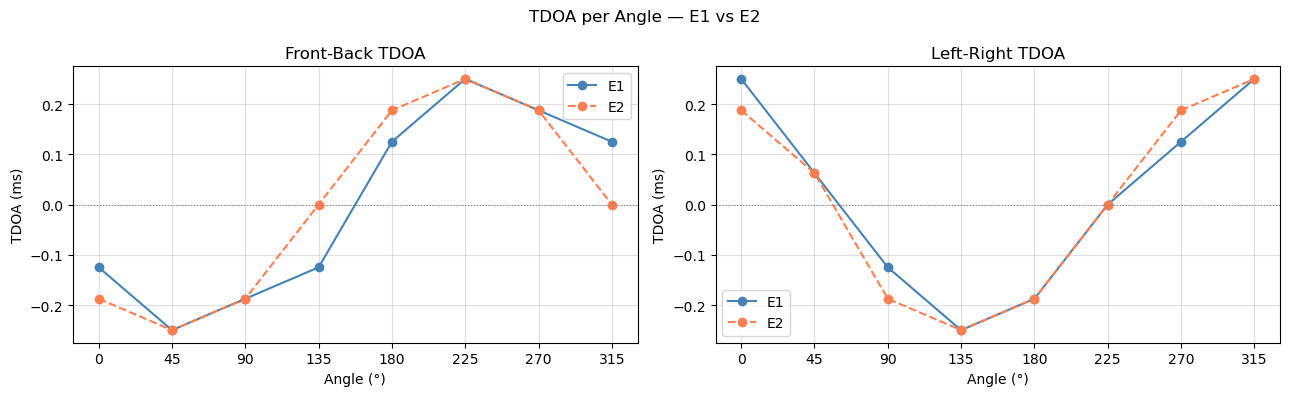

In [11]:
pairs = [
    ('mic_front', 'mic_back',  'FB'),
    ('mic_left',  'mic_right', 'LR'),
    ('mic_front', 'mic_left',  'FL'),
    ('mic_front', 'mic_right', 'FR'),
]

tdoa_rows = []
for ds, base in [('E1', E1), ('E2', E2)]:
    for angle in ANGLES:
        row = {'dataset': ds, 'angle': angle}
        for m1, m2, label in pairs:
            s1 = load(base, angle, '5min', m1)
            s2 = load(base, angle, '5min', m2)
            row[label] = gcc_tdoa(s1, s2)
        tdoa_rows.append(row)

df_tdoa = pd.DataFrame(tdoa_rows)

print("TDOA (ms) — E1 | E2  [FB=front-back, LR=left-right]")
print(f"  {'Angle':>5}  {'E1 FB':>8}  {'E2 FB':>8}  {'E1 LR':>8}  {'E2 LR':>8}")
print("  " + "-"*42)
for angle in ANGLES:
    e1 = df_tdoa[(df_tdoa.dataset=='E1') & (df_tdoa.angle==angle)].iloc[0]
    e2 = df_tdoa[(df_tdoa.dataset=='E2') & (df_tdoa.angle==angle)].iloc[0]
    print(f"  {angle:>4}°  {e1.FB:>+8.3f}  {e2.FB:>+8.3f}  {e1.LR:>+8.3f}  {e2.LR:>+8.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ['FB', 'LR'], ['Front-Back TDOA', 'Left-Right TDOA']):
    for ds, color, ls in [('E1', 'steelblue', '-'), ('E2', 'coral', '--')]:
        sub = df_tdoa[df_tdoa.dataset == ds]
        ax.plot(sub.angle, sub[col], marker='o', color=color, linestyle=ls, label=ds)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set(xlabel='Angle (°)', ylabel='TDOA (ms)', title=title)
    ax.set_xticks(ANGLES); ax.legend(); ax.grid(True, alpha=0.4)
plt.suptitle('TDOA per Angle — E1 vs E2', fontsize=12)
plt.tight_layout(); plt.show()


## 4. Feature Separability
Fisher's discriminant ratio per feature type — tells us which features will actually help the NN distinguish between angles.

Fisher's Discriminant Ratio (higher = better for classification):
  TDOA_LR     71.63  ██████████████████████████████
  TDOA_FB     24.20  ████████████████████████
  IPD_FB       1.60  █
  RMS          0.06  


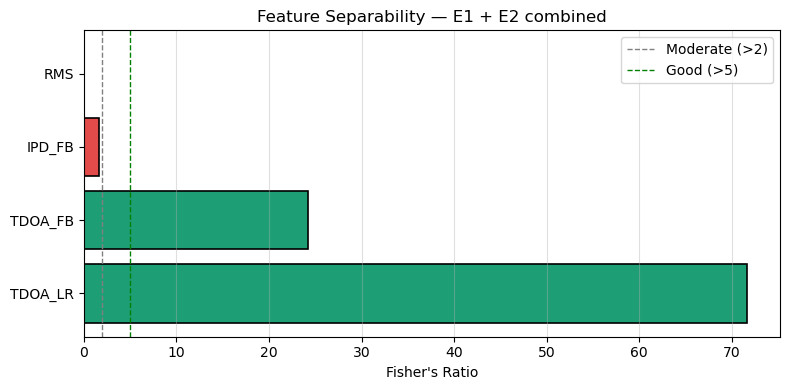

In [12]:
from scipy.signal import hilbert

CHUNK = 2 * SR  # 2-second chunks

def fisher_ratio(values_per_class):
    all_vals = np.concatenate(values_per_class)
    overall_mean = np.mean(all_vals)
    between = np.mean([(np.mean(v) - overall_mean)**2 for v in values_per_class])
    within  = np.mean([np.var(v) for v in values_per_class])
    return between / (within + 1e-10)

features = {k: {a: [] for a in ANGLES} for k in ['RMS','TDOA_FB','TDOA_LR','IPD_FB']}

for ds, base in [('E1',E1), ('E2',E2)]:
    for angle in ANGLES:
        sigs = {m: load(base, angle, '5min', m) for m in MICS}
        n_chunks = min(len(s) for s in sigs.values()) // CHUNK
        for ci in range(n_chunks):
            sl = slice(ci*CHUNK, (ci+1)*CHUNK)
            ch = {m: sigs[m][sl] for m in MICS}
            features['RMS'][angle].append(rms_db(ch['mic_front']))
            features['TDOA_FB'][angle].append(gcc_tdoa(ch['mic_front'], ch['mic_back']))
            features['TDOA_LR'][angle].append(gcc_tdoa(ch['mic_left'],  ch['mic_right']))
            a1 = np.angle(hilbert(ch['mic_front']))
            a2 = np.angle(hilbert(ch['mic_back']))
            features['IPD_FB'][angle].append(float(np.mean(np.degrees(
                np.arctan2(np.sin(a1-a2), np.cos(a1-a2))))))

results = {name: fisher_ratio(list(d.values())) for name, d in features.items()}
results_sorted = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("Fisher's Discriminant Ratio (higher = better for classification):")
for name, score in results_sorted:
    bar = '█' * int(min(score, 30))
    print(f"  {name:<10} {score:6.2f}  {bar}")

fig, ax = plt.subplots(figsize=(8, 4))
names, scores = zip(*results_sorted)
colors = ['#1D9E75' if s > 5 else '#378ADD' if s > 2 else '#E24B4A' for s in scores]
ax.barh(names, scores, color=colors, edgecolor='black', linewidth=1.2)
ax.axvline(2, color='gray', linestyle='--', linewidth=1, label='Moderate (>2)')
ax.axvline(5, color='green', linestyle='--', linewidth=1, label='Good (>5)')
ax.set(xlabel="Fisher's Ratio", title='Feature Separability — E1 + E2 combined')
ax.legend(); ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout(); plt.show()


## 5. Train / Test Split Validation
5min = train, 3min = test. Verify they're different recordings (different RMS/content) so the model can't memorize speech.

5min vs 3min — same angle, same room
          rms_5min   rms_3min  rms_diff
dataset                                
E1      -34.320000 -28.389999      5.93
E2      -32.400002 -28.010000      4.40

RMS diff > 0 across all angles confirms different recording sessions:
dataset  angle  rms_diff
     E1      0      4.10
     E1     45      6.96
     E1     90      5.72
     E1    135      9.87
     E1    180      5.18
     E1    225      7.21
     E1    270      3.70
     E1    315      4.70
     E2      0      2.52
     E2     45      3.90
     E2     90      4.79
     E2    135      3.94
     E2    180      2.24
     E2    225      6.11
     E2    270      3.09
     E2    315      8.58


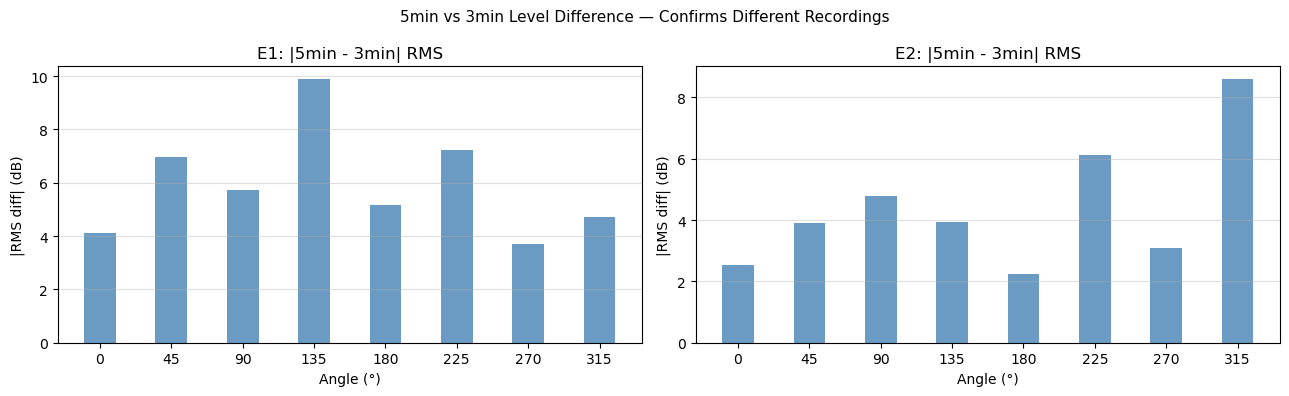

In [13]:
split_rows = []
for ds, base in [('E1', E1), ('E2', E2)]:
    for angle in ANGLES:
        s5 = load(base, angle, '5min', 'mic_front')
        s3 = load(base, angle, '3min', 'mic_front')
        split_rows.append({
            'dataset':  ds,
            'angle':    angle,
            'rms_5min': round(rms_db(s5), 2),
            'rms_3min': round(rms_db(s3), 2),
            'rms_diff': round(abs(rms_db(s5) - rms_db(s3)), 2),
            'mean_diff': round(abs(float(np.mean(s5)) - float(np.mean(s3))), 6),
        })

df_split = pd.DataFrame(split_rows)
print("5min vs 3min — same angle, same room")
print(df_split.groupby('dataset')[['rms_5min', 'rms_3min', 'rms_diff']].mean().round(2))
print("\nRMS diff > 0 across all angles confirms different recording sessions:")
print(df_split[['dataset','angle','rms_diff']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ds in zip(axes, ['E1', 'E2']):
    sub = df_split[df_split.dataset == ds]
    ax.bar(sub.angle, sub.rms_diff, color='steelblue', width=20, alpha=0.8)
    ax.set(xlabel='Angle (°)', ylabel='|RMS diff| (dB)', title=f'{ds}: |5min - 3min| RMS')
    ax.set_xticks(ANGLES)
    ax.grid(True, axis='y', alpha=0.4)
plt.suptitle('5min vs 3min Level Difference — Confirms Different Recordings', fontsize=11)
plt.tight_layout()
plt.show()


## Summary
Quick checklist before moving to feature extraction and model training.

In [14]:
print("=" * 55)
print("  DATASET READINESS CHECKLIST")
print("=" * 55)

total = inv[inv.ok].shape[0]
print(f"  Files found          : {total}/128  {'OK' if total==128 else 'MISSING FILES'}")

clip_total = sum(1 for _, r in df_stats.iterrows() if r.clip)
print(f"  Clipping             : {clip_total} files  {'OK' if clip_total==0 else 'CHECK'}")

rms_e1 = df_stats[df_stats.dataset=='E1'].rms_db.mean()
rms_e2 = df_stats[df_stats.dataset=='E2'].rms_db.mean()
print(f"  Level (E1/E2)        : {rms_e1:.1f} / {rms_e2:.1f} dBFS  (diff {abs(rms_e1-rms_e2):.1f} dB)")

best_feat, best_score = results_sorted[0]
print(f"  Best feature         : {best_feat}  (Fisher={best_score:.2f})")

min_rms_diff = df_split.rms_diff.min()
print(f"  Train/test separation: min RMS diff={min_rms_diff:.2f} dB  {'OK — different recordings' if min_rms_diff > 0 else 'WARNING'}")

print()
print("  Train split : 5min recordings (both E1 + E2)")
print("  Test split  : 3min recordings (both E1 + E2)")
print("  Experiments : S1(E1->E1)  S2(E1->E2)  S3(E2->E1)  S4(E1+E2->both)")
print("=" * 55)


  DATASET READINESS CHECKLIST
  Files found          : 128/128  OK
  Clipping             : 16 files  CHECK
  Level (E1/E2)        : -34.3 / -32.4 dBFS  (diff 1.9 dB)
  Best feature         : TDOA_LR  (Fisher=71.63)
  Train/test separation: min RMS diff=2.24 dB  OK — different recordings

  Train split : 5min recordings (both E1 + E2)
  Test split  : 3min recordings (both E1 + E2)
  Experiments : S1(E1->E1)  S2(E1->E2)  S3(E2->E1)  S4(E1+E2->both)
